In [1]:
import pandas as pd

In [2]:
import os
os.getcwd()

'c:\\Users\\AYUSHMAN SINGH\\OneDrive\\Documents\\E-Commerce-Data-Analytics\\data'

In [3]:
import os

os.listdir()

['ecommerce_analysis.ipynb', 'Online Retail.xlsx', 'online+retail.zip']

In [4]:
os.listdir()

['ecommerce_analysis.ipynb', 'Online Retail.xlsx', 'online+retail.zip']

In [5]:
df = pd.read_excel("Online Retail.xlsx")

In [6]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
df.shape

(541909, 8)

In [8]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [10]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [11]:
df.isnull().sum() / len(df) * 100

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64

In [12]:
df.duplicated().sum()

np.int64(5268)

In [13]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [14]:
(df["Quantity"] < 0).sum()

np.int64(10624)

In [15]:
(df["UnitPrice"] <= 0).sum()

np.int64(2517)

In [16]:
df[df["UnitPrice"] <= 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


In [17]:
df[df["UnitPrice"] <= 0]["Description"].value_counts().head(10)

Description
check                            159
?                                 47
damages                           45
damaged                           43
found                             25
sold as set on dotcom             20
adjustment                        16
Damaged                           14
FRENCH BLUE METAL DOOR SIGN 1      9
thrown away                        9
Name: count, dtype: int64

In [18]:
df[df["UnitPrice"] <= 0]["Description"].value_counts()

Description
check              159
?                   47
damages             45
damaged             43
found               25
                  ... 
???                  1
wet                  1
wet boxes            1
????damages????      1
lost                 1
Name: count, Length: 377, dtype: int64

In [19]:
df_clean = df.copy()

In [20]:
df_clean = df_clean[df_clean["Quantity"] > 0]

In [21]:
df_clean = df_clean[df_clean["UnitPrice"] > 0]

In [22]:
df_clean.shape

(530104, 8)

In [23]:
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

In [24]:
df_clean[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [25]:
df_clean.duplicated().sum()

np.int64(5226)

In [26]:
df_clean = df_clean.drop_duplicates()

In [27]:
df_clean.shape

(524878, 9)

In [28]:
df_clean["CustomerID"].isnull().sum()

np.int64(132186)

In [29]:
df_clean["Description"].isnull().sum()

np.int64(0)

In [30]:
df_clean.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
Revenue             0
dtype: int64

In [31]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [32]:
df_clean["InvoiceDate"].min(), df_clean["InvoiceDate"].max()


(Timestamp('2010-12-01 08:26:00'), Timestamp('2011-12-09 12:50:00'))

In [33]:
df_clean["Year"] = df_clean["InvoiceDate"].dt.year

In [34]:
df_clean["Month"] = df_clean["InvoiceDate"].dt.month

In [35]:
df_clean["Month_Name"] = df_clean["InvoiceDate"].dt.month_name()

In [36]:
df_clean["Year_Month"] = df_clean["InvoiceDate"].dt.to_period("M")

In [37]:
df_clean[["InvoiceDate", "Year", "Month", "Month_Name", "Year_Month"]].head()

,InvoiceDate,Year,Month,Month_Name,Year_Month
0,2010-12-01 08:26:00,2010,12,December,2010-12
1,2010-12-01 08:26:00,2010,12,December,2010-12
2,2010-12-01 08:26:00,2010,12,December,2010-12
3,2010-12-01 08:26:00,2010,12,December,2010-12
4,2010-12-01 08:26:00,2010,12,December,2010-12


In [38]:
df_clean["Day_Name"] = df_clean["InvoiceDate"].dt.day_name()

In [39]:
df_clean["Hour"] = df_clean["InvoiceDate"].dt.hour

In [40]:
df_clean[["InvoiceDate", "Day_Name", "Hour"]].head()

,InvoiceDate,Day_Name,Hour
0,2010-12-01 08:26:00,Wednesday,8
1,2010-12-01 08:26:00,Wednesday,8
2,2010-12-01 08:26:00,Wednesday,8
3,2010-12-01 08:26:00,Wednesday,8
4,2010-12-01 08:26:00,Wednesday,8


In [41]:
df_clean["Country"].value_counts().head(10)

Country
United Kingdom    479985
Germany             9025
France              8392
EIRE                7879
Spain               2479
Netherlands         2359
Belgium             2031
Switzerland         1958
Portugal            1492
Australia           1181
Name: count, dtype: int64

In [42]:
df_clean["Revenue"].sum()

np.float64(10642110.804000001)

In [43]:
df_clean["StockCode"].nunique()

3922

In [44]:
df_clean["CustomerID"].nunique()

4338

In [45]:
df_clean.groupby("Year_Month")["Revenue"].sum()

Year_Month
2010-12     821452.730
2011-01     689811.610
2011-02     522545.560
2011-03     716215.260
2011-04     536968.491
2011-05     769296.610
2011-06     760547.010
2011-07     718076.121
2011-08     757841.380
2011-09    1056435.192
2011-10    1151263.730
2011-11    1503866.780
2011-12     637790.330
Freq: M, Name: Revenue, dtype: float64

In [46]:
df_clean.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: Revenue, dtype: float64

In [47]:
df_clean[df_clean["Description"].str.contains("POSTAGE", case=False, na=False)]["Description"].value_counts()

Description
POSTAGE           1126
DOTCOM POSTAGE     706
Name: count, dtype: int64

In [48]:
df_clean.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

In [49]:
df_clean["InvoiceNo"].nunique()

19960

In [50]:
df_clean["Revenue"].sum() / df_clean["InvoiceNo"].nunique()

np.float64(533.171883967936)

In [51]:
customer_revenue = df_clean.dropna(subset=["CustomerID"]).groupby("CustomerID")["Revenue"].sum()

In [52]:
customer_revenue.mean()

np.float64(2048.688080682342)

In [53]:
customer_revenue.sort_values(ascending=False).head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

In [54]:
df_clean["Quantity"].sum()

np.int64(5572420)

In [55]:
df_clean["Quantity"].sum() / df_clean["InvoiceNo"].nunique()

np.float64(279.17935871743487)

In [56]:
df_clean.groupby("Year_Month")["InvoiceNo"].nunique()

Year_Month
2010-12    1559
2011-01    1086
2011-02    1100
2011-03    1454
2011-04    1246
2011-05    1681
2011-06    1533
2011-07    1475
2011-08    1361
2011-09    1837
2011-10    2040
2011-11    2769
2011-12     819
Freq: M, Name: InvoiceNo, dtype: int64

In [57]:
df_clean["CustomerID"].notna().sum()

np.int64(392692)

In [58]:
df_clean["CustomerID"].isna().sum()

np.int64(132186)

In [59]:
customer_orders = df_clean.dropna(subset=["CustomerID"]).groupby("CustomerID")["InvoiceNo"].nunique()

customer_orders.head()

CustomerID
12346.0    1
12347.0    7
12348.0    4
12349.0    1
12350.0    1
Name: InvoiceNo, dtype: int64

In [61]:
(customer_orders > 1).sum()

np.int64(2845)

In [62]:
(customer_orders > 1).sum() / customer_orders.count() * 100


np.float64(65.58321807284463)

In [63]:
customer_orders.describe()

count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: InvoiceNo, dtype: float64

In [65]:
customer_orders.sort_values(ascending=False).head(10)

CustomerID
12748.0    209
14911.0    201
17841.0    124
13089.0     97
14606.0     93
15311.0     91
12971.0     86
14646.0     73
16029.0     63
13408.0     62
Name: InvoiceNo, dtype: int64

In [66]:
customer_revenue.describe()

count      4338.000000
mean       2048.688081
std        8985.230220
min           3.750000
25%         306.482500
50%         668.570000
75%        1660.597500
max      280206.020000
Name: Revenue, dtype: float64

In [67]:
customer_revenue.sort_values(ascending=False).head(10)


CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

In [68]:
df_clean.dropna(subset=["CustomerID"]).groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

In [69]:
df_clean.dropna(subset=["CustomerID"]).groupby("Year_Month")["CustomerID"].nunique()

Year_Month
2010-12     885
2011-01     741
2011-02     758
2011-03     974
2011-04     856
2011-05    1056
2011-06     991
2011-07     949
2011-08     935
2011-09    1266
2011-10    1364
2011-11    1664
2011-12     615
Freq: M, Name: CustomerID, dtype: int64

In [70]:
customer_revenue.mean()

np.float64(2048.688080682342)

In [71]:
df_clean.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

In [72]:
df_clean.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: Revenue, dtype: float64

In [73]:
total_revenue = df_clean["Revenue"].sum()

total_quantity = df_clean["Quantity"].sum()

total_orders = df_clean["InvoiceNo"].nunique()

total_products = df_clean["StockCode"].nunique()

total_customers = df_clean["CustomerID"].nunique()

average_order_value = total_revenue / total_orders

average_quantity_per_order = total_quantity / total_orders

print("Total Revenue: £", round(total_revenue, 2))
print("Total Quantity Sold:", total_quantity)
print("Total Orders:", total_orders)
print("Unique Products:", total_products)
print("Unique Customers:", total_customers)
print("Average Order Value: £", round(average_order_value, 2))
print("Average Quantity per Order:", round(average_quantity_per_order, 2))

Total Revenue: £ 10642110.8
Total Quantity Sold: 5572420
Total Orders: 19960
Unique Products: 3922
Unique Customers: 4338
Average Order Value: £ 533.17
Average Quantity per Order: 279.18


In [74]:
monthly_revenue = (
    df_clean
    .groupby("Year_Month")["Revenue"]
    .sum()
    .sort_index()
)

monthly_revenue

Year_Month
2010-12     821452.730
2011-01     689811.610
2011-02     522545.560
2011-03     716215.260
2011-04     536968.491
2011-05     769296.610
2011-06     760547.010
2011-07     718076.121
2011-08     757841.380
2011-09    1056435.192
2011-10    1151263.730
2011-11    1503866.780
2011-12     637790.330
Freq: M, Name: Revenue, dtype: float64

In [75]:
monthly_revenue.idxmax(), monthly_revenue.max()

(Period('2011-11', 'M'), np.float64(1503866.78))

In [76]:
monthly_orders = (
    df_clean
    .groupby("Year_Month")["InvoiceNo"]
    .nunique()
    .sort_index()
)

monthly_orders

Year_Month
2010-12    1559
2011-01    1086
2011-02    1100
2011-03    1454
2011-04    1246
2011-05    1681
2011-06    1533
2011-07    1475
2011-08    1361
2011-09    1837
2011-10    2040
2011-11    2769
2011-12     819
Freq: M, Name: InvoiceNo, dtype: int64

In [77]:
monthly_customers = (
    df_clean
    .dropna(subset=["CustomerID"])
    .groupby("Year_Month")["CustomerID"]
    .nunique()
    .sort_index()
)

monthly_customers

Year_Month
2010-12     885
2011-01     741
2011-02     758
2011-03     974
2011-04     856
2011-05    1056
2011-06     991
2011-07     949
2011-08     935
2011-09    1266
2011-10    1364
2011-11    1664
2011-12     615
Freq: M, Name: CustomerID, dtype: int64

In [78]:
country_orders = (
    df_clean
    .groupby("Country")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
)

country_orders.head(10)

Country
United Kingdom    18019
Germany             457
France              392
EIRE                288
Belgium              98
Netherlands          94
Spain                90
Portugal             58
Australia            57
Switzerland          54
Name: InvoiceNo, dtype: int64

In [79]:
top_products_quantity = (
    df_clean
    .groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_quantity

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

In [80]:
top_products_revenue = (
    df_clean
    .groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_revenue

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: Revenue, dtype: float64

In [81]:
customer_revenue = (
    df_clean
    .dropna(subset=["CustomerID"])
    .groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print("Average Revenue per Customer: £",
      round(customer_revenue.mean(), 2))

customer_revenue.head(10)

Average Revenue per Customer: £ 2048.69


CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

In [82]:
customer_orders = (
    df_clean
    .dropna(subset=["CustomerID"])
    .groupby("CustomerID")["InvoiceNo"]
    .nunique()
)

customer_orders.describe()

count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: InvoiceNo, dtype: float64

In [83]:
one_time_customers = (customer_orders == 1).sum()

repeat_customers = (customer_orders > 1).sum()

total_identified_customers = customer_orders.count()

repeat_percentage = (
    repeat_customers / total_identified_customers
) * 100

print("One-time Customers:", one_time_customers)
print("Repeat Customers:", repeat_customers)
print("Repeat Customer %:", round(repeat_percentage, 2))

One-time Customers: 1493
Repeat Customers: 2845
Repeat Customer %: 65.58


In [84]:
top_customers_orders = (
    customer_orders
    .sort_values(ascending=False)
    .head(10)
)

top_customers_orders

CustomerID
12748.0    209
14911.0    201
17841.0    124
13089.0     97
14606.0     93
15311.0     91
12971.0     86
14646.0     73
16029.0     63
13408.0     62
Name: InvoiceNo, dtype: int64

In [85]:
top_customers_revenue = (
    customer_revenue
    .head(10)
)

top_customers_revenue

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

In [86]:
day_revenue = (
    df_clean
    .groupby("Day_Name")["Revenue"]
    .sum()
)

day_revenue

Day_Name
Friday       1837470.491
Monday       1775782.071
Sunday        806790.781
Thursday     2199292.570
Tuesday      2175700.511
Wednesday    1847074.380
Name: Revenue, dtype: float64

In [87]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_revenue = day_revenue.reindex(day_order)

day_revenue

Day_Name
Monday       1775782.071
Tuesday      2175700.511
Wednesday    1847074.380
Thursday     2199292.570
Friday       1837470.491
Saturday             NaN
Sunday        806790.781
Name: Revenue, dtype: float64

In [88]:
missing_customer = df_clean["CustomerID"].isna().sum()

identified_customer = df_clean["CustomerID"].notna().sum()

total_transactions = len(df_clean)

print("Transactions with CustomerID:", identified_customer)
print("Transactions without CustomerID:", missing_customer)

print(
    "Missing CustomerID %:",
    round((missing_customer / total_transactions) * 100, 2)
)

Transactions with CustomerID: 392692
Transactions without CustomerID: 132186
Missing CustomerID %: 25.18


In [89]:
print("Final Shape:", df_clean.shape)

print("\nMissing Values:")
print(df_clean.isnull().sum())

print("\nDuplicate Rows:")
print(df_clean.duplicated().sum())

print("\nDate Range:")
print(df_clean["InvoiceDate"].min())
print(df_clean["InvoiceDate"].max())

print("\nFinal Columns:")
print(df_clean.columns.tolist())

Final Shape: (524878, 15)

Missing Values:
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
Revenue             0
Year                0
Month               0
Month_Name          0
Year_Month          0
Day_Name            0
Hour                0
dtype: int64

Duplicate Rows:
0

Date Range:
2010-12-01 08:26:00
2011-12-09 12:50:00

Final Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'Year', 'Month', 'Month_Name', 'Year_Month', 'Day_Name', 'Hour']


In [90]:
df_clean.to_csv(
    "ecommerce_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [1]:
import pymysql
import pandas as pd

print("PyMySQL:", pymysql.__version__)
print("Pandas:", pd.__version__)

PyMySQL: 2.2.8
Pandas: 3.0.5


In [4]:
import pymysql

connection = pymysql.connect(
    host="localhost",
    user="root",
    password="Ayush@1143",
    database="ecommerce_analytics"
)

print("MySQL connected successfully!")

MySQL connected successfully!


In [5]:
query = "SELECT * FROM ecommerce_data"

df = pd.read_sql(query, connection)

print("Data loaded successfully!")
print(df.shape)

C:\Users\AYUSHMAN SINGH\AppData\Local\Temp\ipykernel_12420\1610732080.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


Data loaded successfully!
(524878, 15)


In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue,Country,Year,Month,Month_Name,Year_Month,Day_Name,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,15.30,United Kingdom,2010,12,December,2010-12,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,20.34,United Kingdom,2010,12,December,2010-12,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,22.00,United Kingdom,2010,12,December,2010-12,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,20.34,United Kingdom,2010,12,December,2010-12,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,20.34,United Kingdom,2010,12,December,2010-12,Wednesday,8


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 524878 entries, 0 to 524877
Data columns (total 15 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    524878 non-null  str           
 1   StockCode    524878 non-null  str           
 2   Description  524878 non-null  str           
 3   Quantity     524878 non-null  int64         
 4   InvoiceDate  524878 non-null  datetime64[us]
 5   UnitPrice    524878 non-null  float64       
 6   CustomerID   524878 non-null  float64       
 7   Revenue      524878 non-null  float64       
 8   Country      524878 non-null  str           
 9   Year         524878 non-null  int64         
 10  Month        524878 non-null  int64         
 11  Month_Name   524878 non-null  str           
 12  Year_Month   524878 non-null  str           
 13  Day_Name     524878 non-null  str           
 14  Hour         524878 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(4), s

In [8]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Revenue        0
Country        0
Year           0
Month          0
Month_Name     0
Year_Month     0
Day_Name       0
Hour           0
dtype: int64

In [9]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue,Year,Month,Hour
count,524878.000000,524878,524878.000000,524878.000000,524878.000000,524878.000000,524878.000000,524878.000000
mean,10.616600,2011-07-04 15:30:16.317049,3.922573,11437.732164,20.275399,2010.921904,7.552237,13.073991
min,1.000000,2010-12-01 08:26:00,0.000000,0.000000,0.000000,2010.000000,1.000000,6.000000
25%,1.000000,2011-03-28 12:13:00,1.250000,0.000000,3.900000,2011.000000,5.000000,11.000000
50%,4.000000,2011-07-20 11:22:00,2.080000,14350.000000,9.920000,2011.000000,8.000000,13.000000
75%,11.000000,2011-10-19 11:41:00,4.130000,16245.000000,17.700000,2011.000000,11.000000,15.000000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000,168469.600000,2011.000000,12.000000,20.000000
std,156.280031,NaN,36.093028,6799.513627,271.693566,0.268323,3.508164,2.442994


In [10]:
total_revenue = df["Revenue"].sum()

print("Total Revenue:", round(total_revenue, 2))

Total Revenue: 10642110.8


In [11]:
total_quantity = df["Quantity"].sum()

print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 5572420


In [12]:
total_orders = df["InvoiceNo"].nunique()

aov = total_revenue / total_orders

print("Average Order Value:", round(aov, 2))

Average Order Value: 533.17


In [14]:
monthly_revenue  = (
    df.groupby("Year_Month")["Revenue"]
    .sum()
    .round(2)
)
monthly_revenue

Year_Month
2010-12     821452.73
2011-01     689811.61
2011-02     522545.56
2011-03     716215.26
2011-04     536968.49
2011-05     769296.61
2011-06     760547.01
2011-07     718076.12
2011-08     757841.38
2011-09    1056435.19
2011-10    1151263.73
2011-11    1503866.78
2011-12     637790.33
Name: Revenue, dtype: float64

In [15]:
country_revenue = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .round(2)
)

country_revenue

Country
United Kingdom    9001744.09
Netherlands        285446.34
EIRE               283140.52
Germany            228678.40
France             209625.37
Australia          138453.81
Spain               61558.56
Switzerland         57067.60
Belgium             41196.34
Sweden              38367.83
Name: Revenue, dtype: float64

In [16]:
product_revenue = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .round(2)
)

product_revenue

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: Revenue, dtype: float64

In [17]:
product_quantity = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

product_quantity

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

In [18]:
customer_revenue = (
    df.dropna(subset=["CustomerID"])
      .groupby("CustomerID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .round(2)
)

customer_revenue

CustomerID
0.0        1754901.91
14646.0     280206.02
18102.0     259657.30
17450.0     194390.79
16446.0     168472.50
14911.0     143711.17
12415.0     124914.53
14156.0     117210.08
17511.0      91062.38
16029.0      80850.84
Name: Revenue, dtype: float64

In [19]:
customer_orders = (
    df.dropna(subset=["CustomerID"])
      .groupby("CustomerID")["InvoiceNo"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

customer_orders

CustomerID
0.0        1428
12748.0     209
14911.0     201
17841.0     124
13089.0      97
14606.0      93
15311.0      91
12971.0      86
14646.0      73
16029.0      63
Name: InvoiceNo, dtype: int64

In [20]:
orders_per_customer = (
    df.dropna(subset=["CustomerID"])
      .groupby("CustomerID")["InvoiceNo"]
      .nunique()
)

customer_type = orders_per_customer.apply(
    lambda x: "One-time" if x == 1 else "Repeat"
)

customer_type.value_counts()

InvoiceNo
Repeat      2846
One-time    1493
Name: count, dtype: int64

In [21]:
repeat_percentage = (
    (customer_type == "Repeat").sum()
    / len(customer_type)
) * 100

print("Repeat Customer Percentage:", round(repeat_percentage, 2), "%")

Repeat Customer Percentage: 65.59 %


In [23]:
day_revenue = (
    df.groupby("Day_Name")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .round(2)
)

day_revenue

Day_Name
Thursday     2199292.57
Tuesday      2175700.51
Wednesday    1847074.38
Friday       1837470.49
Monday       1775782.07
Sunday        806790.78
Name: Revenue, dtype: float64

In [24]:
day_orders = (
    df.groupby("Day_Name")["InvoiceNo"]
      .nunique()
      .sort_values(ascending=False)
)

day_orders

Day_Name
Thursday     4246
Wednesday    3690
Tuesday      3554
Friday       3140
Monday       3126
Sunday       2204
Name: InvoiceNo, dtype: int64

In [26]:
hour_revenue = (
    df.groupby("Hour")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .round(2)
)

hour_revenue

Hour
10    1444814.77
12    1439324.66
15    1350333.31
13    1261195.20
11    1236573.29
14    1177907.52
9      990054.99
16     752487.96
17     460963.92
8      283750.68
18     144603.61
19      50204.95
7       31059.21
20      18832.48
6           4.25
Name: Revenue, dtype: float64

In [27]:
hour_orders = (
    df.groupby("Hour")["InvoiceNo"]
      .nunique()
      .sort_values(ascending=False)
)

hour_orders

Hour
12    3220
13    2753
14    2457
11    2396
10    2361
15    2336
9     1484
16    1335
17     667
8      566
18     192
19     146
7       29
20      18
6        1
Name: InvoiceNo, dtype: int64

## Visualization

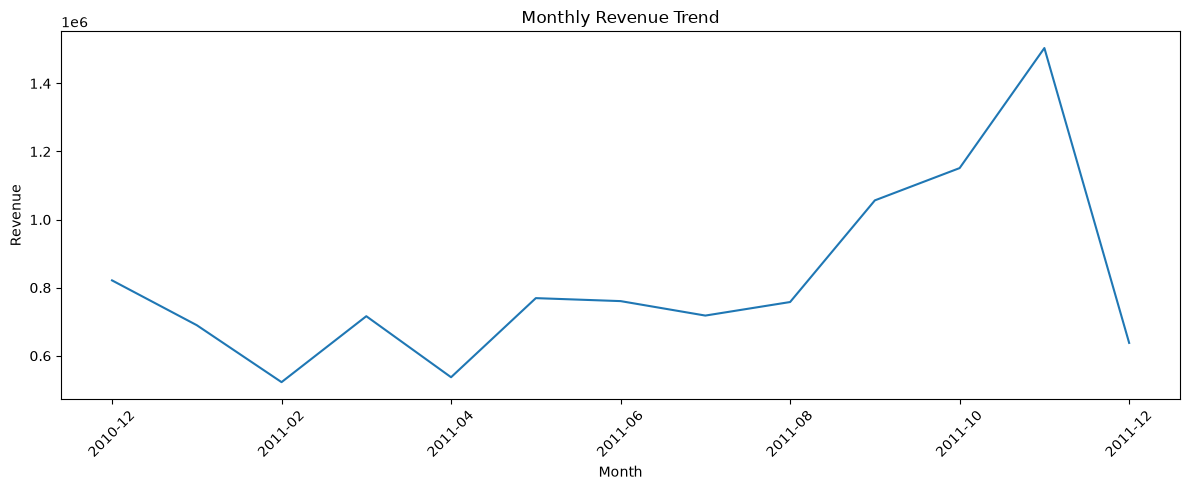

In [28]:
import matplotlib.pyplot as plt

monthly_revenue.plot(kind="line", figsize=(12, 5))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

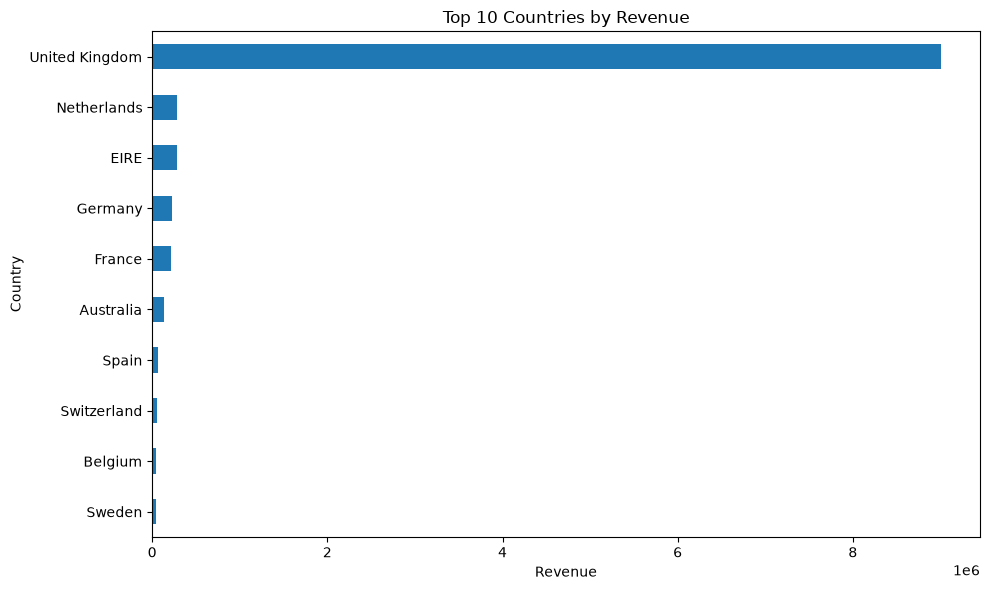

In [29]:
country_revenue.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

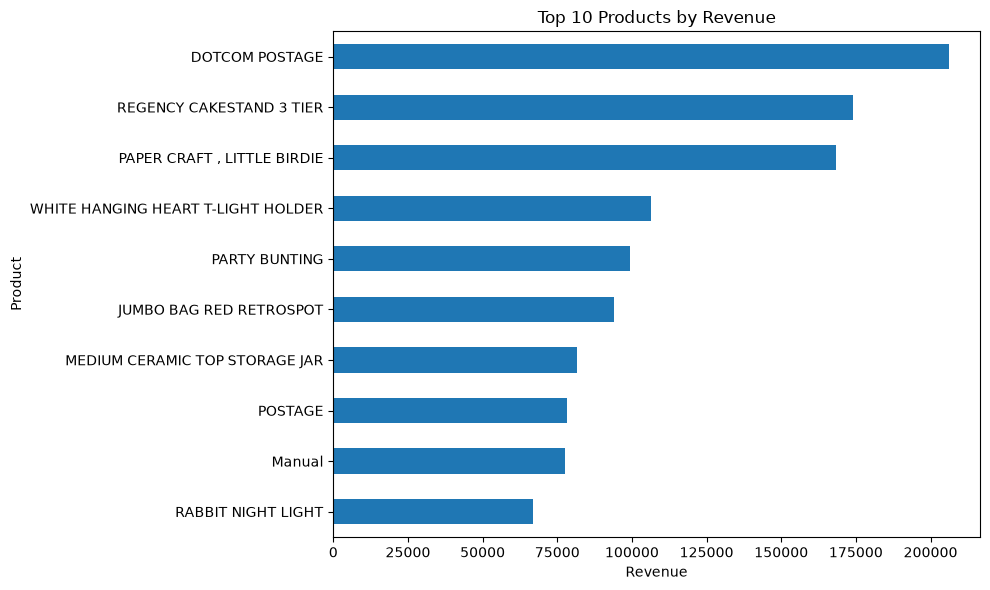

In [30]:
product_revenue.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

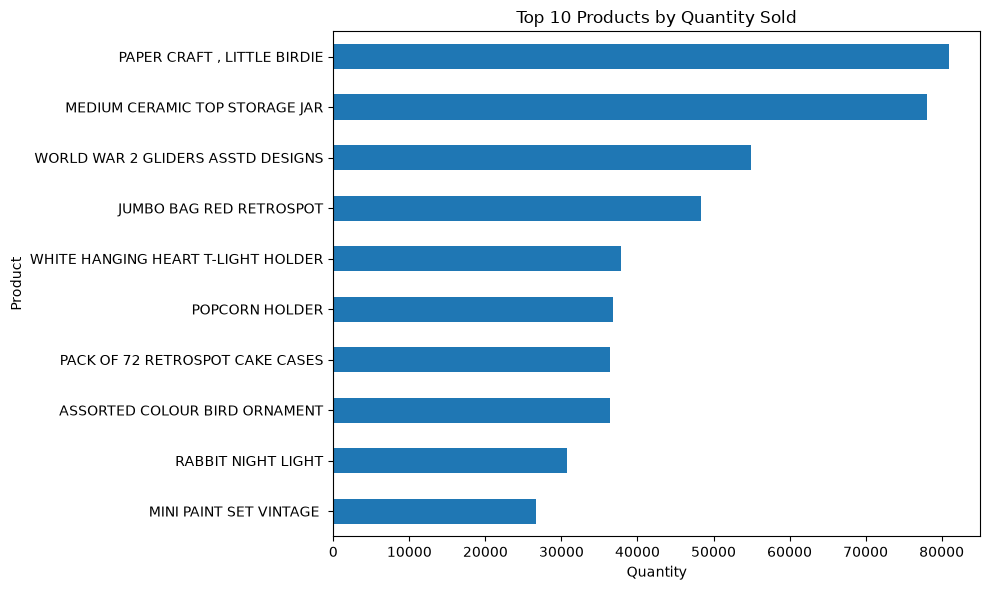

In [31]:
product_quantity.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

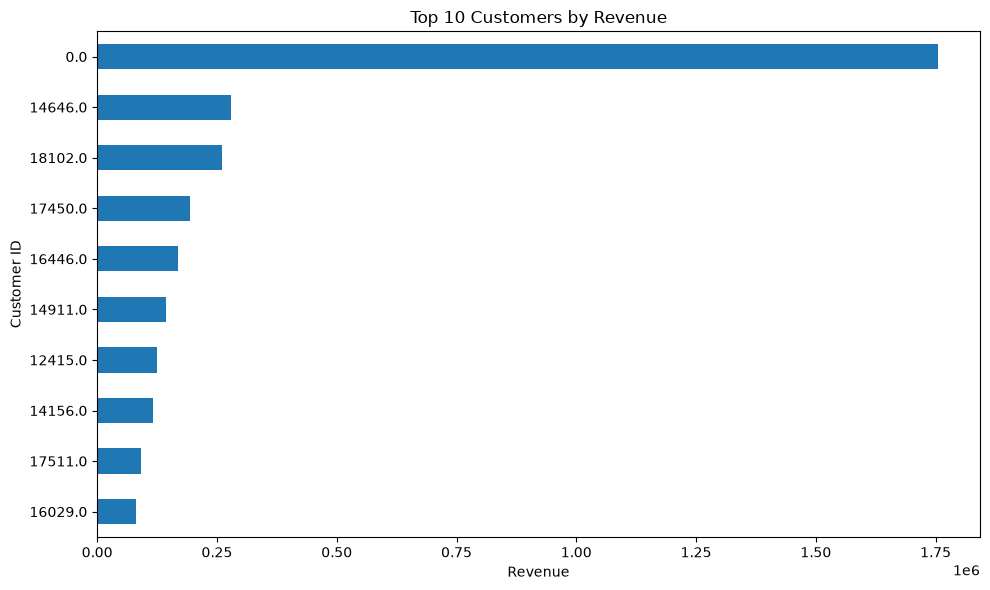

In [32]:
customer_revenue.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.show()

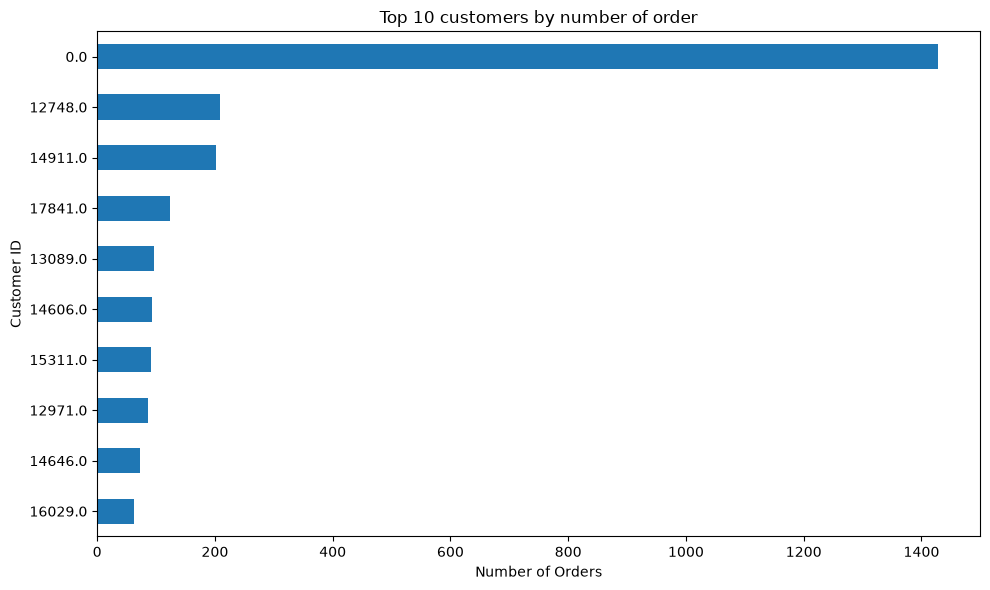

In [34]:
customer_orders.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 10 customers by number of order")
plt.xlabel("Number of Orders")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.show()



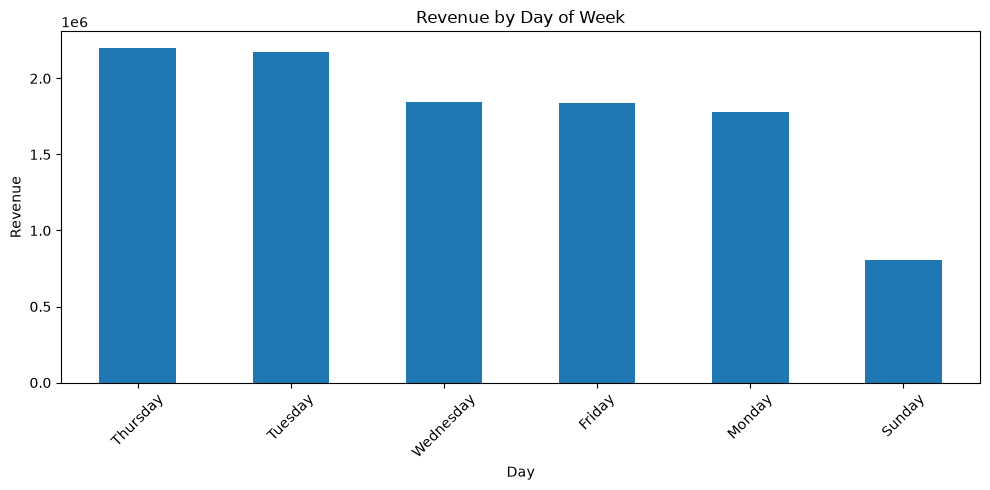

In [39]:
day_revenue.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

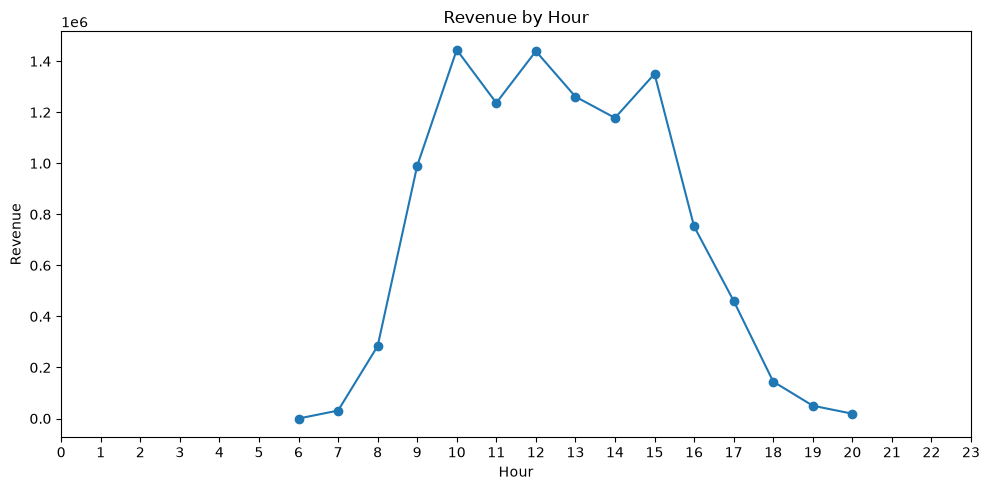

In [44]:
hour_revenue.sort_index().plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Revenue by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

In [45]:
monthly_customers = (
    df.dropna(subset=["CustomerID"])
      .groupby("Year_Month")["CustomerID"]
      .nunique()
)

monthly_customers

Year_Month
2010-12     886
2011-01     742
2011-02     759
2011-03     975
2011-04     857
2011-05    1057
2011-06     992
2011-07     950
2011-08     936
2011-09    1267
2011-10    1365
2011-11    1665
2011-12     616
Name: CustomerID, dtype: int64

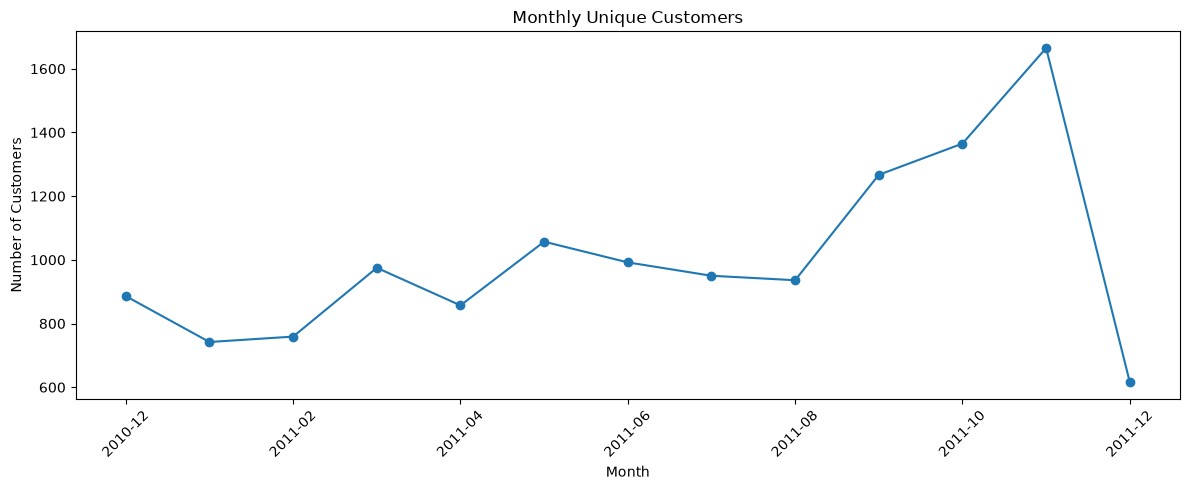

In [46]:
monthly_customers.plot(
    kind="line",
    marker="o",
    figsize=(12, 5)
)

plt.title("Monthly Unique Customers")
plt.xlabel("Month")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

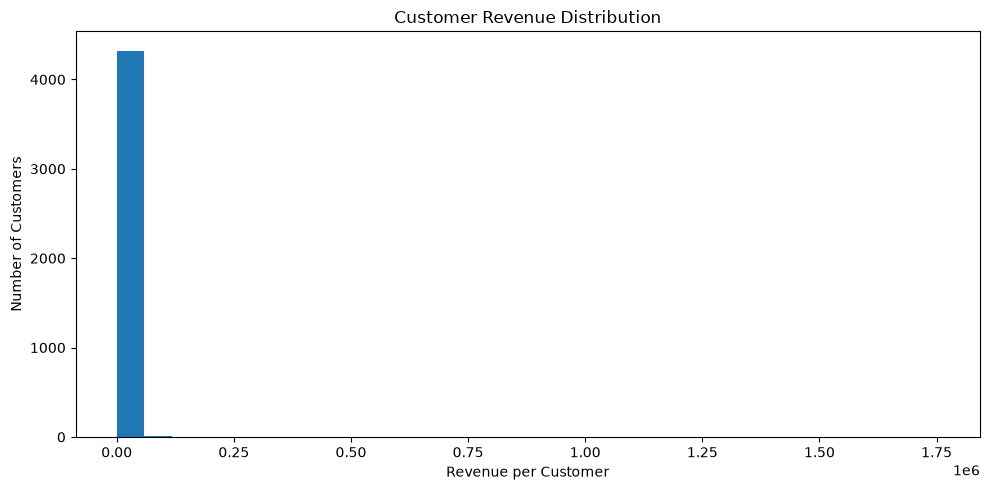

In [47]:
customer_revenue_all = (
    df.dropna(subset=["CustomerID"])
      .groupby("CustomerID")["Revenue"]
      .sum()
)

customer_revenue_all.plot(
    kind="hist",
    bins=30,
    figsize=(10, 5)
)

plt.title("Customer Revenue Distribution")
plt.xlabel("Revenue per Customer")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

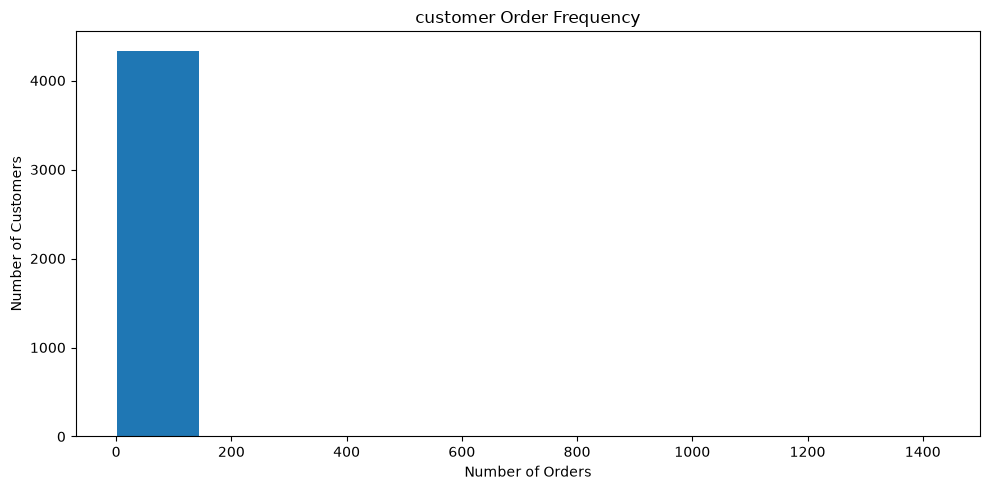

In [50]:
orders_per_customer.plot(
    kind="hist",
    bins=10,
    figsize=(10,5)
)

plt.title("customer Order Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

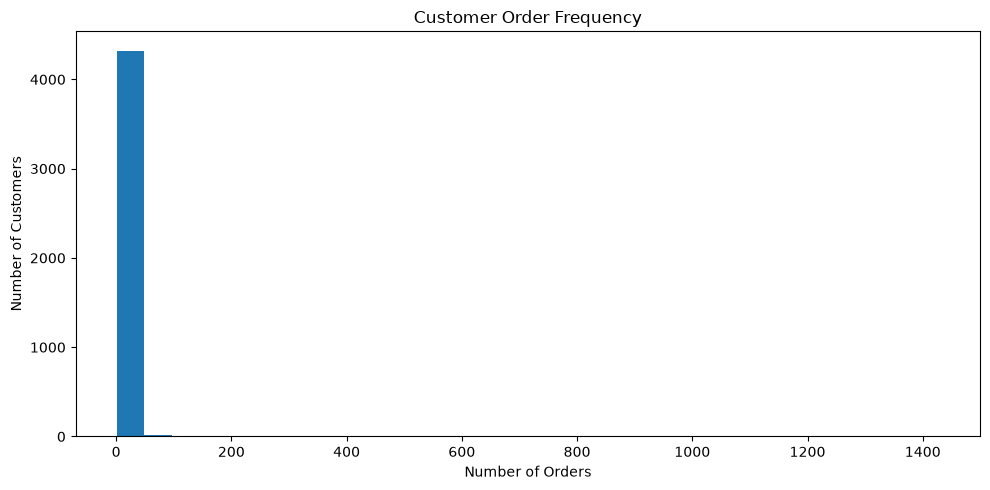

In [51]:
orders_per_customer.plot(
    kind="hist",
    bins=30,
    figsize=(10, 5)
)

plt.title("Customer Order Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

# business KPIs and insights

In [52]:
total_revenue = df["Revenue"].sum()
total_orders = df["InvoiceNo"].nunique()
total_customers = df["CustomerID"].nunique()
total_products = df["StockCode"].nunique()
total_quantity = df["Quantity"].sum()

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Identified Customers:", total_customers)
print("Unique Products:", total_products)
print("Total Quantity Sold:", total_quantity)

Total Revenue: 10642110.8
Total Orders: 19960
Identified Customers: 4339
Unique Products: 3922
Total Quantity Sold: 5572420


In [53]:
aov = total_revenue / total_orders

print("Average Order Value:", round(aov, 2))

Average Order Value: 533.17


In [54]:
repeat_rate = (
    (orders_per_customer > 1).sum()
    / len(orders_per_customer)
) * 100

print("Repeat Customer Rate:", round(repeat_rate, 2), "%")

Repeat Customer Rate: 65.59 %


In [55]:
avg_customer_revenue = (
    customer_revenue_all.mean()
)

print(
    "Average Revenue per Identified Customer:",
    round(avg_customer_revenue, 2)
)

Average Revenue per Identified Customer: 2452.66


In [56]:
print("===== E-COMMERCE SALES ANALYSIS =====")
print("Total Revenue: £", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Identified Customers:", total_customers)
print("Unique Products:", total_products)
print("Total Quantity Sold:", total_quantity)
print("Average Order Value: £", round(aov, 2))
print("Repeat Customer Rate:", round(repeat_rate, 2), "%")
print("Average Revenue per Customer: £", round(avg_customer_revenue, 2))

===== E-COMMERCE SALES ANALYSIS =====
Total Revenue: £ 10642110.8
Total Orders: 19960
Identified Customers: 4339
Unique Products: 3922
Total Quantity Sold: 5572420
Average Order Value: £ 533.17
Repeat Customer Rate: 65.59 %
Average Revenue per Customer: £ 2452.66


In [57]:
df.to_csv("ecommerce_python_analysis.csv", index=False)

print("CSV saved successfully!")

CSV saved successfully!


In [58]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Notebook analysis completed successfully")

Rows: 524878
Columns: 15
Notebook analysis completed successfully
